<a href="https://colab.research.google.com/github/aWolander/google-colab/blob/main/Federated%20Learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [33]:
from __future__ import annotations
import copy
import torch
from torch import nn
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets
from torchvision.transforms import ToTensor, Normalize, Compose
import matplotlib.pyplot as plt
import random
import numpy as np
try:
    device = torch.accelerator.current_accelerator().type if torch.accelerator.is_available() else "cpu" # i get an error when i run this locally
except:
    device="cpu"

transform = Compose([
    ToTensor(),
    Normalize((0.485, 0.456, 0.406), (0.229, 0.224, 0.225)),
]) # https://github.com/facebookresearch/dino/blob/7c446df5b9f45747937fb0d72314eb9f7b66930a/eval_image_retrieval.py#L106

CIFAR100 = datasets.CIFAR100(
  root="data",
  download=True,
  transform=transform
)


In [34]:
def main() -> None:
    """
    Loads CIFAR-100 dataset and splits it into training, validation, and test sets.
    Then performs an IID client split and tests the data distribution.
    """
    K = 100  # number of clients
    CIFAR100 = datasets.CIFAR100(
        root="data",
        download=True,
        transform=ToTensor()
    )
    total_len = len(CIFAR100)
    train_len = int(0.7 * total_len)
    val_len = int(0.15 * total_len)
    test_len = total_len - train_len - val_len

    train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(
        CIFAR100, [train_len, val_len, test_len]
    )

    client_datasets = split_data_iid(train_dataset, K)
    test_split(client_datasets)


def create_label_indexing(dataset: Dataset) -> dict[int, list[int]]:
    """
    Creates a dictionary mapping each class label to the list of indices where it appears.

    Args:
        dataset: Dataset object (e.g. CIFAR100 or Subset).

    Returns:
        A dictionary mapping label -> list of indices.
    """
    label_index = {i: [] for i in range(100)}
    for idx, (_, label) in enumerate(dataset):
        label_index[label].append(idx)
    return label_index


def split_data_non_iid(dataset: Dataset, K: int, N_c: int = 100) -> list[Subset]:
    """
    Splits the dataset into K non-IID subsets based on label distribution.

    Args:
        dataset: PyTorch dataset.
        K: Number of clients.
        N_c: Number of labels per client.

    Returns:
        List of K Subsets representing client datasets.
    """
    index_split = [[] for _ in range(K)]
    label_index = create_label_indexing(dataset)
    available_labels = {i: random.sample(range(100), N_c) for i in range(K)}
    labels_exhausted = [False] * K

    while not all(labels_exhausted):
        for client in range(K):
            if not available_labels[client]:
                labels_exhausted[client] = True
                continue
            for label in available_labels[client][:]:
                if not label_index[label]:
                    available_labels[client].remove(label)
                    continue
                index_split[client].append(label_index[label].pop())

    for indices in index_split:
        random.shuffle(indices)

    return [Subset(dataset, indices) for indices in index_split]


def split(l: list[int], n: int) -> list[list[int]]:
    """
    Splits a list into n parts in a round-robin fashion.

    Args:
        l: List to split.
        n: Number of splits.

    Returns:
        A list of n sublists.
    """
    return [l[i::n] for i in range(n)]


def split_data_iid(dataset: Dataset, K: int) -> list[Subset]:
    """
    Splits the dataset IID among K clients.

    Args:
        dataset: PyTorch dataset.
        K: Number of clients.

    Returns:
        List of K Subsets representing IID client datasets.
    """
    index_split = [[] for _ in range(K)]
    label_index = create_label_indexing(dataset)

    for label in range(100):
        split_indices = split(label_index[label], K)
        for client in range(K):
            index_split[client] += split_indices[client]

    for indices in index_split:
        random.shuffle(indices)

    return [Subset(dataset, indices) for indices in index_split]


def test_split(client_datasets: list[Subset]) -> None:
    """
    Plots the label distribution across client datasets.

    Args:
        client_datasets: List of Subsets, each representing a client.
    """
    bottom = np.zeros(100)

    for client_id, dataset in enumerate(client_datasets):
        occurrences = np.zeros(100)
        for _, label in dataset:
            occurrences[label] += 1

        non_zero = occurrences[occurrences > 0]
        print(
            f"Client {client_id}: "
            f"Classes = {np.count_nonzero(occurrences)}, "
            f"Mean = {non_zero.mean():.2f}, Std = {non_zero.std():.2f}"
        )

        plt.bar(range(100), occurrences, bottom=bottom, label=f"Client {client_id}")
        bottom += occurrences

    plt.xlabel("Class label")
    plt.ylabel("Number of samples")
    plt.title("Client Data Distribution")
    plt.show()




In [46]:
'''This is done seperately so that saving and loading the models does not grant
a different dataset. A bit annoying to have to change K here but what can you do'''
K=5
N_c = 20

train_dataset, validate_dataset, test_dataset = torch.utils.data.random_split(CIFAR100, [0.7,0.15,0.15])

split_dataset_iid = split_data_iid(train_dataset, K)
split_dataset_non_iid = split_data_non_iid(train_dataset, K, N_c)
split_train_dataloader_iid = [DataLoader(subset, batch_size=100) for subset in split_dataset_iid]
split_train_dataloader_non_iid = [DataLoader(subset, batch_size=100) for subset in split_dataset_non_iid]


train_dataloader = DataLoader(train_dataset, batch_size=100)
test_dataloader = DataLoader(test_dataset, batch_size=100)
validate_dataloader = DataLoader(validate_dataset, batch_size=100)

In [56]:
#import logging

#logging.basicConfig(level=logging.INFO)
#logger = logging.getLogger(__name__)

class DinoFullModel(nn.Module):
    """
    A wrapper around the DINO ViT-S/16 model.
    Adds a custom classification head and includes training and evaluation utilities.
    """

    def __init__(self, learning_rate: float = 1e-3, epochs: int = 20) -> None:
        """
        Initializes the model with a DINO backbone and custom classification head.

        Args:
            learning_rate (float): Learning rate for optimizer.
            epochs (int): Number of training epochs.
        """
        super().__init__()

        self.learning_rate = learning_rate
        self.epochs = epochs

        # Load pretrained DINO model
        self.model = torch.hub.load('facebookresearch/dino:main', 'dino_vits16').to(device)

        # Replace head with a new classifier for CIFAR
        self.model.head = nn.Sequential(
            nn.Linear(self.model.embed_dim, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, 128),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(128, 100)
        ).to(device)

        # Loss and optimizer
        self.loss_fn = nn.CrossEntropyLoss()
        self.optimizer = torch.optim.SGD(self.parameters(), lr=self.learning_rate)
        self.scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(self.optimizer, T_max=self.epochs)

        # Performance tracking
        self.training_loss_history = []
        self.training_accuracy_history = []
        self.validate_loss_history = []
        self.validate_accuracy_history = []

        # For saving and Loading
        self.current_epoch = 1
        self.loss = None

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model.head(self.model(x))

    def train_model(self, dataloader: DataLoader, validate_dataloader: DataLoader|None = None, filepath: str|False=False) -> None:
        """
        Trains the model with optional validation and checkpointing.
        """
        self.train()

        for epoch in range(self.current_epoch, self.epochs+1):
            print(f"Epoch {epoch}/{self.epochs}")
            running_loss, total_correct, total_samples = 0.0, 0, 0
            dataset_size = len(dataloader.dataset)

            for X, y in dataloader:
                X, y = X.to(device), y.to(device)

                outputs = self.forward(X)
                self.loss = self.loss_fn(outputs, y)

                self.loss.backward()
                self.optimizer.step()
                self.optimizer.zero_grad()

                running_loss += self.loss.item() * X.size(0)
                total_correct += (outputs.argmax(dim=1) == y).sum().item()
                total_samples += X.size(0)
                if total_samples%5000 == 0:
                    print(f"Samples processed: {total_samples} out of {dataset_size}" )

            epoch_loss = running_loss / total_samples
            epoch_acc = total_correct / total_samples
            self.training_loss_history.append(epoch_loss)
            self.training_accuracy_history.append(epoch_acc)

            print(f"Train Loss: {epoch_loss:.4f}, Accuracy: {epoch_acc:.4f}")

            if validate_dataloader:
                val_loss, val_acc = self.test_model(validate_dataloader)
                self.validate_loss_history.append(val_loss)
                self.validate_accuracy_history.append(val_acc)
                print(f"Validation Loss: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

            self.scheduler.step()
            self.current_epoch = epoch
            if filepath:
                self.save_model(filepath)


    def test_model(self, dataloader: DataLoader) -> tuple[float, float]:
        """
        Evaluates the model on a test/validation dataloader.
        """
        self.eval()
        total_loss, total_correct, total_samples = 0.0, 0, 0

        with torch.no_grad():
            for X, y in dataloader:
                X, y = X.to(device), y.to(device)
                outputs = self.forward(X)
                loss = self.loss_fn(outputs, y)

                total_loss += loss.item() * X.size(0)
                total_correct += (outputs.argmax(dim=1) == y).sum().item()
                total_samples += X.size(0)

        return total_loss / total_samples, total_correct / total_samples

    def save_model(self, filepath: str) -> None:
        """
        Saves model weights and optimizer state.

        Args:
            filepath (str): Path to save the checkpoint.
        """
        torch.save({
            'epoch': self.current_epoch+1,
            'model_state_dict': self.state_dict(),
            'optimizer_state_dict': self.optimizer.state_dict(),
            'training_loss_history': self.training_loss_history,
            'training_accuracy_history': self.training_accuracy_history,
            'validate_loss_history': self.validate_loss_history,
            'validate_accuracy_history': self.validate_accuracy_history

        }, filepath)
        print(f"Model saved to {filepath}")

    def load_model(self, filepath: str) -> None:
        """
        Loads model weights and optimizer state from a checkpoint.

        Args:
            filepath (str): Path to the saved checkpoint.
        """
        checkpoint = torch.load(filepath, map_location=device)
        self.load_state_dict(checkpoint['model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['optimizer_state_dict'])
        self.current_epoch = checkpoint['epoch']
        self.training_loss_history = checkpoint['training_loss_history']
        self.training_accuracy_history = checkpoint['training_accuracy_history']
        self.validate_loss_history = checkpoint['validate_loss_history']
        self.validate_accuracy_history = checkpoint['validate_accuracy_history']
        print(f"Model loaded from {filepath}")

    def plot_performance(self) -> None:
        """
        Plots training and validation loss and accuracy curves.
        """
        fig, axs = plt.subplots(1, 2, figsize=(12, 5))
        if self.training_loss_history:
          axs[0].plot(self.training_loss_history, label='Train Loss')
        if self.validate_loss_history:
            axs[0].plot(self.validate_loss_history, label='Val Loss')
        axs[0].set_title('Loss')
        axs[0].legend()
        axs[0].grid(True)
        if self.training_accuracy_history:
          axs[1].plot(self.training_accuracy_history, label='Train Accuracy')
        if self.validate_accuracy_history:
            axs[1].plot(self.validate_accuracy_history, label='Val Accuracy')
        axs[1].set_title('Accuracy')
        axs[1].legend()
        axs[1].grid(True)

        plt.tight_layout()
        plt.show()

In [48]:
class FL_client(DinoFullModel):
    '''
    Basically just the single model, but with addition and scaling functionality.
    To facilitate FedAvg more easily.
    '''
    def __init__(self) -> None:
        super().__init__()

    def __add__(self, other: FL_client) -> FL_client:
        assert isinstance(other, FL_client)
        temp_client = copy.deepcopy(self)
        # torch.load(other.state_dict)??
        with torch.no_grad():
            for (name, param), (_, other_param) in zip(temp_client.named_parameters(), other.named_parameters()):
                param.copy_(param + other_param.to(device))
        return temp_client

    def __mul__(self, multiplier: float|int) -> FL_client:
        assert isinstance(multiplier, float|int)
        temp_client = copy.deepcopy(self)
        with torch.no_grad():
                for name, param in temp_client.named_parameters():
                    param.copy_(param * multiplier)

    def __rmul__(self, multiplier: float|int) -> FL_client:
        return self.__mul__(multiplier)

    def __sub__(self, other: FL_client) -> FL_client:
        assert isinstance(other, FL_client)
        return self + (-other)

class FL_server():
    def __init__(self, K: int) -> None:
        self.model = DinoFullModel().to(device)

        self.K = K
        self.training_rounds = 10

        self.current_training_round = 1

        self.loss_fn = nn.CrossEntropyLoss()
        self.clients = []
        for i in range(self.K):
            self.clients.append(FL_client()) # pointers? should be fine

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.model.forward(x)

    def FedAvg(self, dataloaders_list: list[DataLoader],C: float, validate_dataloader: DataLoader|None = None, file_path: str|None = None) -> None:
        for training_round in range(self.current_training_round, self.training_rounds+1):
            print(f"----------- TRAINING ROUND {training_round}. -----------")
            m = max(C*self.K, 1)
            rand_set_clients = random.sample(range(self.K), m)
            client_model_sum = None
            m_t = 0
            for client_id in rand_set_clients:
                temp_client = self.clients[client_id]
                temp_loader = dataloaders_list[client_id]

                print(f"----------- TRAIN LOOP FOR CLIENT {client_id}. -----------")
                temp_client.train_model(temp_loader)
                n_k = len(temp_loader.dataset)
                m_t += n_k
                # Easier than instantiating an empty model
                if client_model_sum is None:
                    client_model_sum = n_k*temp_client
                else:
                    client_model_sum = client_model_sum + n_k*temp_client

            client_model_sum = (1/m_t) * client_model_sum
            self.model = client_model_sum.model
            self.current_training_round = training_round
            if validate_dataloader:
                print(f"----------- VALIDATION FOR SERVER. -----------")
                val_loss, val_acc = self.test_model(validate_dataloader)
                self.model.validate_loss_history.append(val_loss)
                self.model.validate_accuracy_history.append(val_acc)
                print(f"Validation Loss For Server: {val_loss:.4f}, Accuracy: {val_acc:.4f}")

            if file_path:
                self.save_model(file_path)


    def test_model(self, dataloader: DataLoader) -> tuple(float, float):
        #print(f"Validation Loss: {avg_loss:.4f}, Correct: {total_correct} out of {len(dataloader)}, Accuracy: {accuracy:.2%}")
        return self.model.test_model(dataloader)

    def plot_performance(self) -> None:
        self.model.plot_performance()

    def save_model(self, filepath: str) -> None:
        """
        Saves model weights and optimizer state.

        Args:
            filepath (str): Path to save the checkpoint.
        """
        save_dict = {}

        save_dict[f"server_model_state_dict"] = self.model.state_dict()
        save_dict[f"server_optimizer_state_dict"] = self.model.optimizer.state_dict()
        save_dict[f"server_round"] = self.current_training_round+1
        save_dict[f"server_validate_loss_history"] = self.model.validate_loss_history
        save_dict[f"server_validate_accuracy_history"] = self.model.validate_loss_history

        for client_id in range(self.K):
            save_dict[f"client{client_id}model_state_dict"] = self.clients[client_id].state_dict()
            save_dict[f"client{client_id}optimizer_state_dict"] = self.clients[client_id].optimizer.state_dict()
            save_dict[f"client{client_id}_epoch"] = self.clients[client_id].current_epoch+1

            save_dict[f"client{client_id}_training_loss_history"] = self.clients[client_id].training_loss_history
            save_dict[f"client{client_id}_training_accuracy_history"] = self.clients[client_id].accuracy_loss_history
            save_dict[f"client{client_id}_validate_loss_history"] = self.clients[client_id].training_loss_history
            save_dict[f"client{client_id}_validate_accuracy_history"] = self.clients[client_id].validate_accuracy_history
            print(f"Client {client_id} Model save to {filepath}")

        torch.save({save_dict}, filepath)
        print(f"Server and clients saved to {filepath}")

    def load_model(self, filepath: str) -> None:
        """
        Loads model weights and optimizer state from a checkpoint.

        Args:
            filepath (str): Path to the saved checkpoint.
        """
        checkpoint = torch.load(filepath, map_location=device)
        self.model.load_state_dict(checkpoint['server_model_state_dict'])
        self.optimizer.load_state_dict(checkpoint['server_optimizer_state_dict'])
        self.current_training_round = checkpoint['server_round']

        for client_id in range(self.K):
            self.clients[client_id].load_state_dict(checkpoint[f"client{client_id}model_state_dict"])
            self.clients[client_id].optimizer.load_state_dict(checkpoint[f"client{client_id}optimizer_state_dict"])
            self.clients[client_id].current_epoch = checkpoint[f"client{client_id}_epoch"]

            self.clients[client_id].training_loss_history = checkpoint[f"client{client_id}_training_loss_history"]
            self.clients[client_id].training_accuracy_history = checkpoint[f"client{client_id}_training_accuracy_history"]
            self.clients[client_id].validate_loss_history = checkpoint[f"client{client_id}_validate_loss_history"]
            self.clients[client_id].validate_accuracy_history = checkpoint[f"client{client_id}_validate_accuracy_history"]
            self.clients[client_id].to(device)

            print(f"Client {client_id} Model loaded from {filepath}")




Using cache found in /root/.cache/torch/hub/facebookresearch_dino_main


Model loaded from test_model.pt


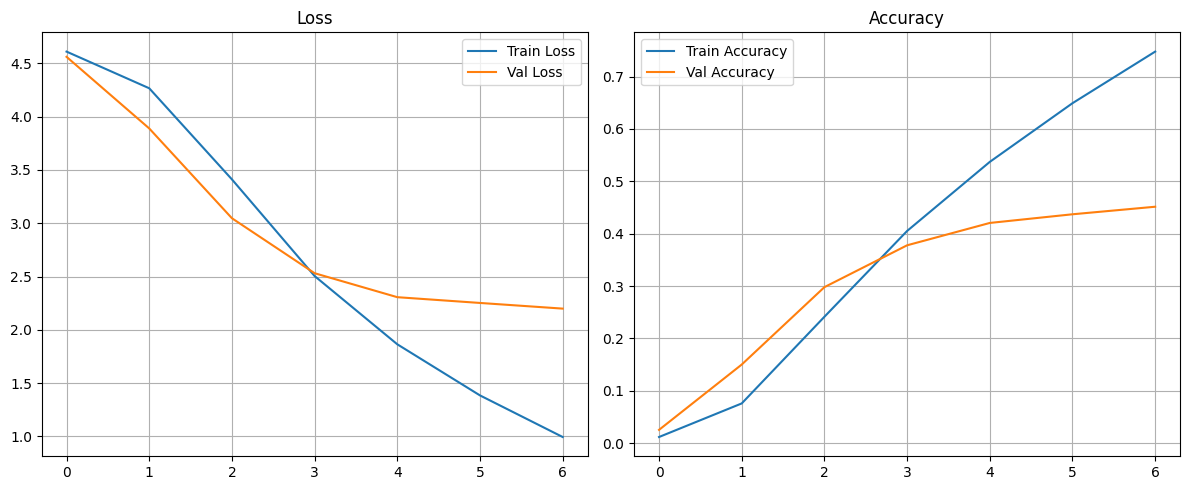

Epoch 8/20
Samples processed: 5000 out of 35000
Samples processed: 10000 out of 35000
Samples processed: 15000 out of 35000
Samples processed: 20000 out of 35000
Samples processed: 25000 out of 35000
Samples processed: 30000 out of 35000
Samples processed: 35000 out of 35000
Train Loss: 2.5928, Accuracy: 0.3627
Validation Loss: 2.3021, Accuracy: 0.4584
Model saved to test_model.pt
Epoch 9/20
Samples processed: 5000 out of 35000
Samples processed: 10000 out of 35000
Samples processed: 15000 out of 35000
Samples processed: 20000 out of 35000
Samples processed: 25000 out of 35000
Samples processed: 30000 out of 35000
Samples processed: 35000 out of 35000
Train Loss: 0.6957, Accuracy: 0.8172
Validation Loss: 2.1704, Accuracy: 0.4825
Model saved to test_model.pt
Epoch 10/20
Samples processed: 5000 out of 35000
Samples processed: 10000 out of 35000
Samples processed: 15000 out of 35000
Samples processed: 20000 out of 35000
Samples processed: 25000 out of 35000
Samples processed: 30000 out of

KeyboardInterrupt: 

In [58]:
'''
TODO:
Batch normalization, probably. I think I read somewhere that the facebook model needs this. someone also needs to look up how to make good use of the model
  - Added normalization transform to images from facebook github
Version control and checkpointing.
  - added version control, checkpoitning left //Gustav
  - Added checkpointing. Not tested yet //Gustav
Testing and hyperparameter tuning. also model head architecture
  - Added very simple model head architecture
gradient mask TaLoS thing. Also expanding this to FL. This is a big one.
Plot accuracy and loss method in DinoFullModel
  - added // Gustav
Type hinting
  - added // Gustav
'''

def FL_test():
    FL = FL_server(K)
    FL.FedAvg(train_dataloader, 1, validate_dataloader=validate_dataloader)
    FL.test_model(test_dataloader)

def single_test():
    model = DinoFullModel().to(device)
    #for param in model.parameters():
    #    print(param.shape)
    model.load_model(filepath="test_model.pt")
    model.plot_performance()

    model.train_model(train_dataloader, validate_dataloader=validate_dataloader, filepath="test_model.pt")
    model.plot_performance()
    print("Done!")

single_test()
